---
## 1. Importación de librerías


- **pandas** → manipulación de datos
- **matplotlib** → gráficos base
- **seaborn** → gráficos estadísticos más sencillos y bonitos
- **os** → para crear carpetas si no existen

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Estilo visual para todos los gráficos del notebook
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

# Creamos la carpeta donde guardaremos los gráficos (si no existe)
os.makedirs('../docs/img', exist_ok=True)

print('Librerías cargadas correctamente')

Librerías cargadas correctamente


---
## 2. Carga del dataset

In [2]:
df = pd.read_csv('../data/raw/gym_churn_us.csv', sep=';')

print(f'Filas:    {df.shape[0]}')
print(f'Columnas: {df.shape[1]}')

Filas:    4000
Columnas: 14


In [ ]:
COLS_AFECTADAS_POR_BUG = [
    'Avg_additional_charges_total',
    'Avg_class_frequency_total',
    'Avg_class_frequency_current_month'
]

# Detectamos el bug: estas columnas llegan como texto, con varios puntos, fruto de una confusión entre separador decimal y separador de miles en el CSV original de Kaggle.
print('Ejemplos del bug de exportación (valores en bruto, antes de cualquier conversión):')
for col in COLS_AFECTADAS_POR_BUG:
    print(f'  {col}: {df[col].iloc[1]!r}')

# Probamos a reconstruir el valor real (tomando el primer bloque como parte
# entera y uniendo el resto como parte decimal) y lo contrastamos contra
# valores reales conocidos de fuentes externas que procesaron este mismo
# dataset. Resultado: la reconstrucción falla en una proporción muy alta
# de filas (hasta el 43.7% de los valores de frecuencia quedan fuera de
# cualquier rango posible, por ejemplo más de 600 visitas/semana).
#
# El desplazamiento de la coma no es constante fila a fila, así que no
# existe una fórmula que lo corrija al 100%. Documentamos el bug como
# limitación conocida (ver business_case.md, apartado 2.1) y EXCLUIMOS
# estas 3 columnas del análisis en vez de seguir trabajando con datos
# parcialmente corruptos sin saber cuáles son las filas afectadas.
df = df.drop(columns=COLS_AFECTADAS_POR_BUG)

# Month_to_end_contract NO tiene este bug (ya viene como número válido
# del 1 al 12), así que no necesita ningún tratamiento.
print()
print(f'Columnas eliminadas por el bug de datos: {COLS_AFECTADAS_POR_BUG}')
print(f'Columnas restantes: {df.shape[1]}')

Ejemplos del bug de exportación (valores en bruto, antes de cualquier conversión):
  Avg_additional_charges_total: '11.320.293.765.105.800'
  Avg_class_frequency_total: '19.229.360.550.418.100'
  Avg_class_frequency_current_month: '19.102.435.215.196.400'

Columnas eliminadas por el bug de datos: ['Avg_additional_charges_total', 'Avg_class_frequency_total', 'Avg_class_frequency_current_month']
Columnas restantes: 11


## 3. Primeras filas

In [4]:
df.head()

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Month_to_end_contract,Lifetime,Churn
0,1,1,1,1,0,6,1,29,5.0,3,0
1,0,1,0,0,1,12,1,31,12.0,7,0
2,0,1,1,0,1,1,0,28,1.0,2,0
3,0,1,1,1,1,12,1,33,12.0,2,0
4,1,1,1,1,1,1,0,26,1.0,3,0


### 3.1 Últimas filas


In [5]:
df.tail()

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Month_to_end_contract,Lifetime,Churn
3995,1,1,1,0,1,12,0,33,12.0,8,0
3996,0,1,0,0,1,1,1,29,1.0,1,1
3997,1,1,1,1,1,12,0,28,11.0,2,0
3998,0,1,1,1,1,6,0,32,5.0,3,0
3999,1,0,1,0,0,12,1,30,12.0,1,0


### 3.2 Tipos de datos y valores no nulos


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   gender                 4000 non-null   int64  
 1   Near_Location          4000 non-null   int64  
 2   Partner                4000 non-null   int64  
 3   Promo_friends          4000 non-null   int64  
 4   Phone                  4000 non-null   int64  
 5   Contract_period        4000 non-null   int64  
 6   Group_visits           4000 non-null   int64  
 7   Age                    4000 non-null   int64  
 8   Month_to_end_contract  4000 non-null   float64
 9   Lifetime               4000 non-null   int64  
 10  Churn                  4000 non-null   int64  
dtypes: float64(1), int64(10)
memory usage: 343.9 KB


---
## 4. Clasificación de variables

In [7]:
# Variables numéricas 
VARS_NUMERICAS = [
    'Age',
    'Contract_period',
    'Month_to_end_contract',
    'Lifetime'
]

# Variables binarias (solo toman valor 0 o 1)
VARS_BINARIAS = [
    'gender',
    'Near_Location',
    'Partner',
    'Promo_friends',
    'Phone',
    'Group_visits'
]

# Variable objetivo: lo que queremos predecir
TARGET = 'Churn'

print('Variables clasificadas')

Variables clasificadas


---
## 5. Calidad del dataset

Antes de analizar nada, comprobamos que los datos están limpios. 

### 5.1 Valores nulos

In [8]:
nulos = df.isnull().sum()

print('Valores nulos por columna:')
print(nulos)
print(f'\nTotal de columnas con algún nulo: {(nulos > 0).sum()}')

Valores nulos por columna:
gender                   0
Near_Location            0
Partner                  0
Promo_friends            0
Phone                    0
Contract_period          0
Group_visits             0
Age                      0
Month_to_end_contract    0
Lifetime                 0
Churn                    0
dtype: int64

Total de columnas con algún nulo: 0


### 5.2 Registros duplicados

In [9]:
duplicados = df.duplicated().sum()

print(f'Registros duplicados: {duplicados}')

if duplicados == 0:
    print('No hay registros duplicados')
else:
    print(f'Hay {duplicados} filas con el mismo perfil en estas 11 columnas.')
    print('No son el mismo socio repetido: con las 3 columnas excluidas por el bug')
    print('de datos (ver celda anterior) incluidas, había 0 duplicados. Son socios')
    print('distintos que comparten perfil demográfico. NO se eliminan.')

Registros duplicados: 859
Hay 859 filas con el mismo perfil en estas 11 columnas.
No son el mismo socio repetido: con las 3 columnas excluidas por el bug
de datos (ver celda anterior) incluidas, había 0 duplicados. Son socios
distintos que comparten perfil demográfico. NO se eliminan.


---
## 6. Estadísticas descriptivas

In [10]:
df.describe().round(2)

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Month_to_end_contract,Lifetime,Churn
count,4000.00,4000.00,4000.00,4000.00,4000.0,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00
mean,0.51,0.85,0.49,0.31,0.9,4.68,0.41,29.18,4.32,3.72,0.27
std,0.50,0.36,0.50,0.46,0.3,4.55,0.49,3.26,4.19,3.75,0.44
min,0.00,0.00,0.00,0.00,0.0,1.00,0.00,18.00,1.00,0.00,0.00
25%,0.00,1.00,0.00,0.00,1.0,1.00,0.00,27.00,1.00,1.00,0.00
50%,1.00,1.00,0.00,0.00,1.0,1.00,0.00,29.00,1.00,3.00,0.00
75%,1.00,1.00,1.00,1.00,1.0,6.00,1.00,31.00,6.00,5.00,1.00
max,1.00,1.00,1.00,1.00,1.0,12.00,1.00,41.00,12.00,31.00,1.00


**Primeras observaciones:**

- `Age`: socios entre 18 y 41 años. Media en torno a los 29.
- `Lifetime`: entre 0 y 31 meses. Muchos socios son recientes.
- `Contract_period`: solo toma valores 1, 6 o 12 — mensual, semestral o anual.
- `Avg_additional_charges_total`, `Avg_class_frequency_total` y `Avg_class_frequency_current_month`: excluidas del análisis por el bug de exportación documentado en la celda anterior (ver business_case.md, apartado 2.1).

---
## 7. Análisis de Churn

- **0** → el socio sigue activo
- **1** → el socio se ha dado de baja


In [11]:
# Recuento absoluto
print('Distribución de Churn:')
print(df[TARGET].value_counts())

# Porcentaje
print('\nEn porcentaje:')
pct = df[TARGET].value_counts(normalize=True) * 100
print(pct.round(1))

Distribución de Churn:
Churn
0    2939
1    1061
Name: count, dtype: int64

En porcentaje:
Churn
0    73.5
1    26.5
Name: proportion, dtype: float64


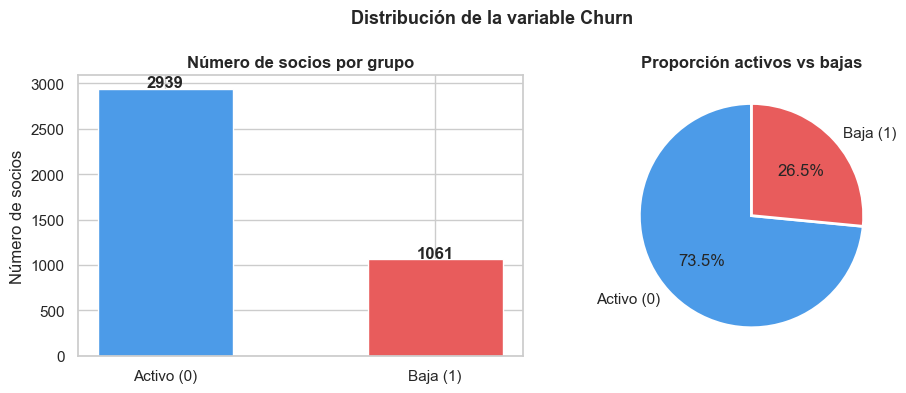

In [12]:
# Visualizamos la distribución con un gráfico de barras
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# --- Gráfico izquierdo: recuentos ---
conteo = df[TARGET].value_counts()
colores = ['#4C9BE8', '#E85C5C']

axes[0].bar(
    ['Activo (0)', 'Baja (1)'],
    conteo.values,
    color=colores,
    edgecolor='white',
    width=0.5
)
axes[0].set_title('Número de socios por grupo', fontweight='bold')
axes[0].set_ylabel('Número de socios')

for i, valor in enumerate(conteo.values):
    axes[0].text(i, valor + 20, str(valor), ha='center', fontweight='bold')

# --- Gráfico derecho: porcentajes ---
axes[1].pie(
    conteo.values,
    labels=['Activo (0)', 'Baja (1)'],
    autopct='%1.1f%%',
    colors=colores,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('Proporción activos vs bajas', fontweight='bold')

plt.suptitle('Distribución de la variable Churn', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../docs/img/01_distribucion_churn.png', bbox_inches='tight')
plt.show()


---
## 8. Análisis de variables numéricas

Para las variables numéricas, la mejor forma de ver si hay diferencias entre 
socios activos y socios que se han ido es superponer sus distribuciones en el mismo gráfico.

Usamos `hue='Churn'` en seaborn para colorear por grupo automáticamente:
- 🔵 Azul = socios activos (Churn = 0)
- 🔴 Rojo = socios que se han dado de baja (Churn = 1)

### 8.1 Histogramas de variables continuas

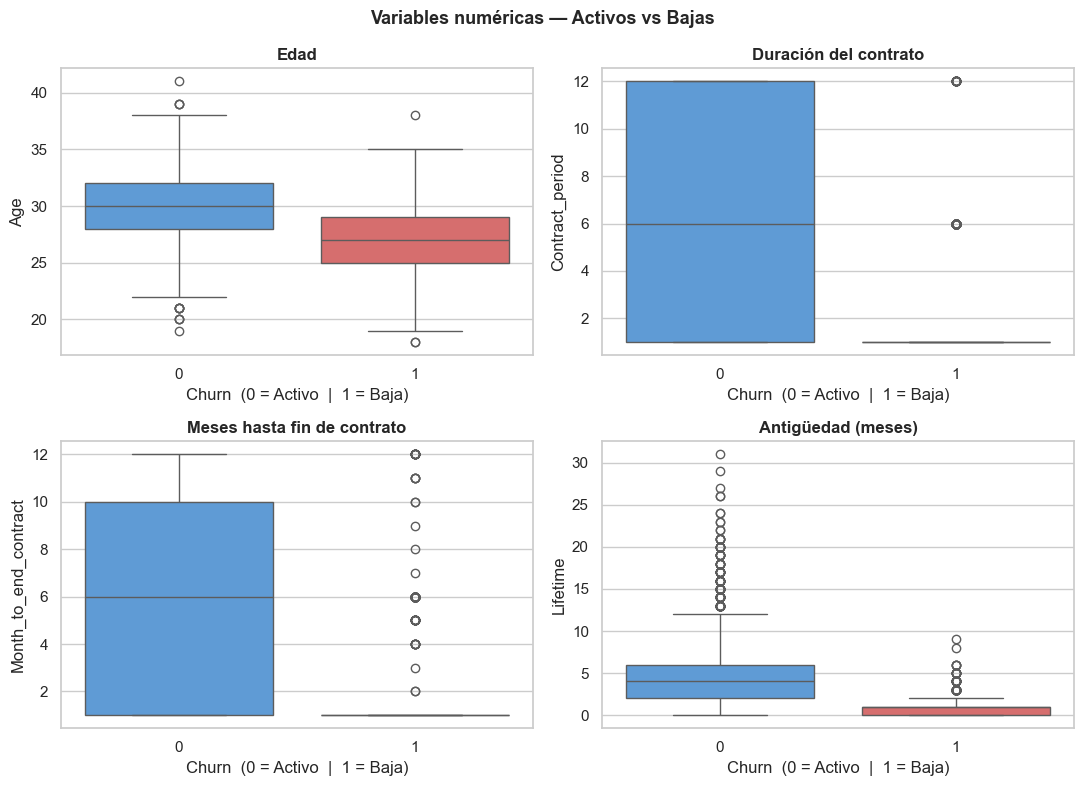

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
axes = axes.flatten()

TITULOS = {
    'Age':                                'Edad',
    'Contract_period':                    'Duración del contrato',
    'Month_to_end_contract':              'Meses hasta fin de contrato',
    'Lifetime':                           'Antigüedad (meses)'
}

for i, variable in enumerate(VARS_NUMERICAS):
    sns.boxplot(
        data=df,
        x=TARGET,
        y=variable,
        hue=TARGET,
        palette={0: '#4C9BE8', 1: '#E85C5C'},
        legend=False,
        ax=axes[i]
    )
    axes[i].set_title(TITULOS[variable], fontweight='bold')
    axes[i].set_xlabel('Churn  (0 = Activo  |  1 = Baja)')
    
plt.suptitle('Variables numéricas — Activos vs Bajas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../docs/img/02_boxplots_continuas.png', bbox_inches='tight')
plt.show()

**¿Qué observamos?**

- **Edad**: los socios más jóvenes se concentran más entre los que abandonan.
- **Frecuencia media este mes**: los que se van tienen frecuencias más bajas 
en el mes actual que los que se quedan. Señal importante.
- **Gasto adicional medio**: los socios activos gastan más en servicios adicionales.
- **Frecuencia media histórica**: diferencia más sutil, pero los que se van tienen media histórica menor.

### 8.2 Comparativa de medias por grupo Churn

In [14]:
# Calculamos la media de cada variable para cada grupo de Churn
comparativa = df.groupby(TARGET)[VARS_NUMERICAS].mean().round(2).T

# Renombramos las columnas para que sean más claras
comparativa.columns = ['Media — Activo (0)', 'Media — Baja (1)']

# Añadimos la diferencia entre grupos
comparativa['Diferencia'] = (comparativa['Media — Baja (1)'] - comparativa['Media — Activo (0)']).round(2)

comparativa

,Media — Activo (0),Media — Baja (1),Diferencia
Age,29.98,26.99,-2.99
Contract_period,5.75,1.73,-4.02
Month_to_end_contract,5.28,1.66,-3.62
Lifetime,4.71,0.99,-3.72


**Lectura de la tabla:**

- `Lifetime`: los socios que se van llevan de media menos meses en el gimnasio.
- `Contract_period`: los que se van tienen contratos de menor duración (más mensuales).
- `Month_to_end_contract`: los que se van tienen menos meses de contrato por delante.
- Las dos columnas de frecuencia: los que se van vienen menos, especialmente este mes.

---
## 9. Análisis de variables binarias

### 9.1 Tabla de tasa de churn por variable binaria

In [15]:
resultados = []

for variable in VARS_BINARIAS:
    # Calculamos la tasa de churn (media del Churn) para cada valor de la variable
    tasa = df.groupby(variable)[TARGET].mean() * 100
    resultados.append({
        'Variable': variable,
        'Churn cuando valor = 0 (%)': round(tasa[0], 1),
        'Churn cuando valor = 1 (%)': round(tasa[1], 1),
        'Diferencia (puntos)': round(tasa[0] - tasa[1], 1)
    })

# Convertimos la lista en un DataFrame y ordenamos por diferencia
df_binarias = pd.DataFrame(resultados)
df_binarias = df_binarias.sort_values('Diferencia (puntos)', ascending=False)
df_binarias

,Variable,Churn cuando valor = 0 (%),Churn cuando valor = 1 (%),Diferencia (puntos)
5,Group_visits,33.0,17.3,15.7
1,Near_Location,39.7,24.1,15.6
3,Promo_friends,31.3,15.8,15.5
2,Partner,33.3,19.4,14.0
4,Phone,26.7,26.5,0.2
0,gender,26.5,26.6,-0.1


### 9.2 Gráfico — Tasa de churn en las 3 variables más relevantes

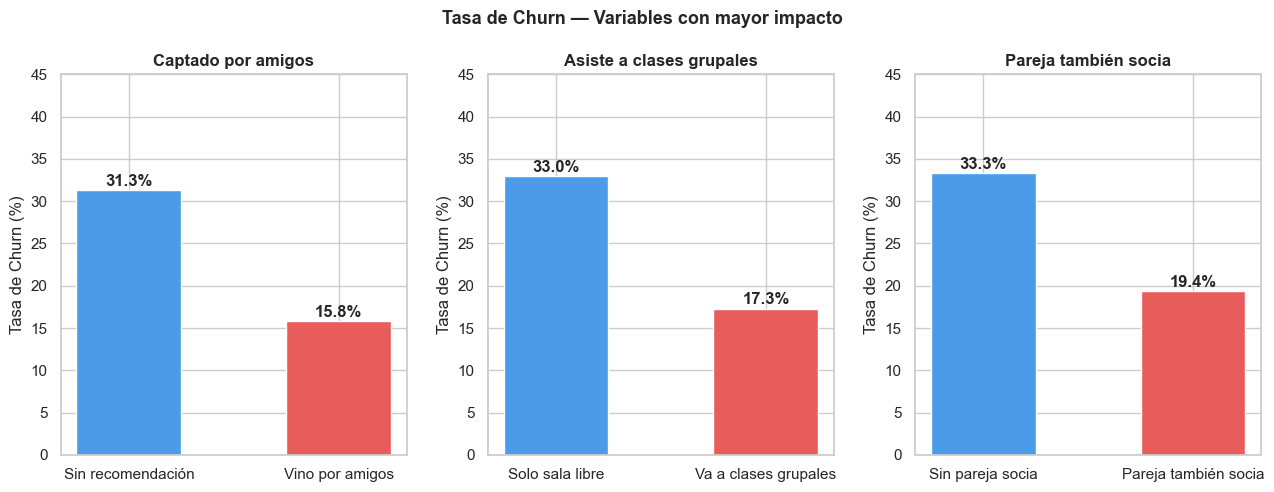

In [16]:
TITULOS_BINARIAS = {
    'Promo_friends': 'Captado por amigos',
    'Group_visits':  'Asiste a clases grupales',
    'Partner':       'Pareja también socia'
}   

# Las tres variables con mayor impacto en el churn
variables_clave = ['Promo_friends', 'Group_visits', 'Partner']
etiquetas = {
    'Promo_friends': ['Sin recomendación', 'Vino por amigos'],
    'Group_visits':  ['Solo sala libre', 'Va a clases grupales'],
    'Partner':       ['Sin pareja socia', 'Pareja también socia']
}

fig, axes = plt.subplots(1, 3, figsize=(13, 5))

for i, variable in enumerate(variables_clave):
    tasa = df.groupby(variable)[TARGET].mean() * 100
    barras = axes[i].bar(
        etiquetas[variable],
        tasa.values,
        color=['#4C9BE8', '#E85C5C'],
        edgecolor='white',
        width=0.5
    )
    # Etiqueta de porcentaje encima de cada barra
    for barra, valor in zip(barras, tasa.values):
        axes[i].text(
            barra.get_x() + barra.get_width() / 2,
            barra.get_height() + 0.5,
            f'{valor:.1f}%',
            ha='center', fontweight='bold'
        )
    axes[i].set_title(TITULOS_BINARIAS[variable], fontweight='bold')
    axes[i].set_ylabel('Tasa de Churn (%)')
    axes[i].set_ylim(0, 45)

plt.suptitle('Tasa de Churn — Variables con mayor impacto', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../docs/img/03_churn_variables_clave.png', bbox_inches='tight')
plt.show()

### 9.3 Gráfico — Churn por tipo de contrato

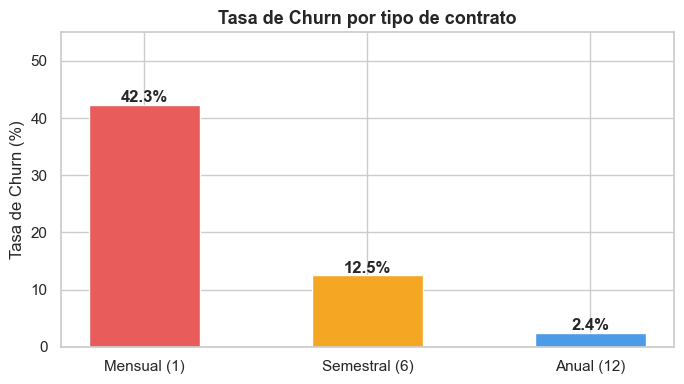

In [17]:
tasa_contrato = df.groupby('Contract_period')[TARGET].mean() * 100

plt.figure(figsize=(7, 4))
barras = plt.bar(
    ['Mensual (1)', 'Semestral (6)', 'Anual (12)'],
    tasa_contrato.values,
    color=['#E85C5C', '#F5A623', '#4C9BE8'],
    edgecolor='white',
    width=0.5
)

for barra, valor in zip(barras, tasa_contrato.values):
    plt.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() + 0.5,
        f'{valor:.1f}%',
        ha='center', fontweight='bold', fontsize=12
    )

plt.title('Tasa de Churn por tipo de contrato', fontweight='bold', fontsize=13)
plt.ylabel('Tasa de Churn (%)')
plt.ylim(0, 55)
plt.tight_layout()
plt.savefig('../docs/img/04_churn_por_contrato.png', bbox_inches='tight')
plt.show()

---
## 10. Correlación con el target

La correlación mide la relación lineal entre dos variables. 
Va de -1 a +1:

- **Próxima a -1**: cuando una sube, la otra baja (correlación negativa)
- **Próxima a +1**: cuando una sube, la otra también sube (correlación positiva)
- **Próxima a 0**: no hay relación lineal

Para el Churn, una correlación **negativa** significa que esa variable protege contra el abandono. 
Una correlación **positiva** significa que está asociada a mayor riesgo de baja.

### 10.1 Matriz de correlación completa

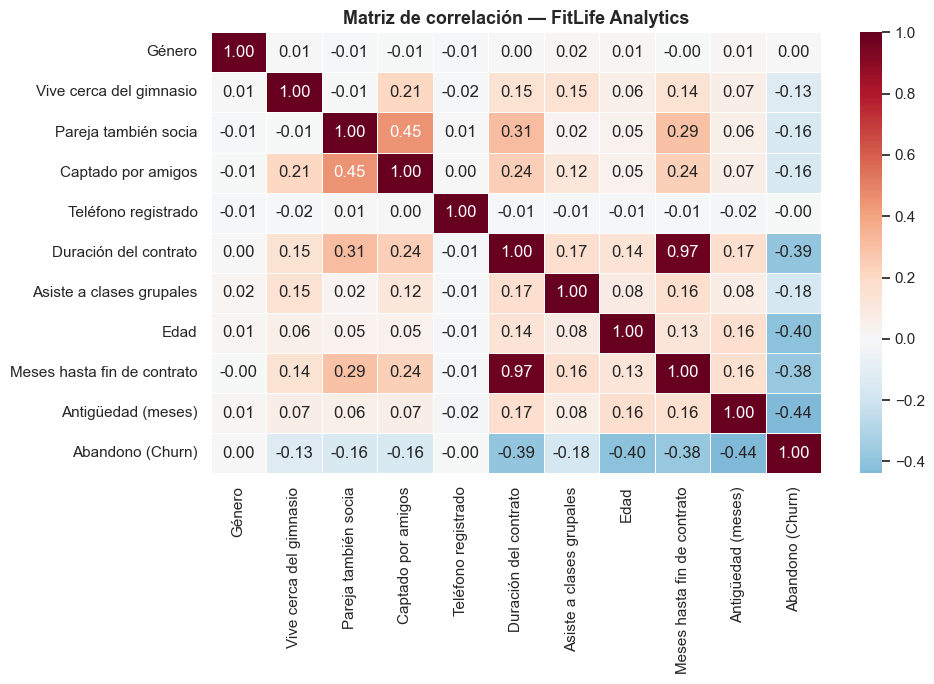

In [18]:
NOMBRES_ES = {
    'gender':                             'Género',
    'Near_Location':                      'Vive cerca del gimnasio',
    'Partner':                            'Pareja también socia',
    'Promo_friends':                      'Captado por amigos',
    'Phone':                              'Teléfono registrado',
    'Contract_period':                    'Duración del contrato',
    'Group_visits':                       'Asiste a clases grupales',
    'Age':                                'Edad',
    'Month_to_end_contract':              'Meses hasta fin de contrato',
    'Lifetime':                           'Antigüedad (meses)',
    'Churn':                              'Abandono (Churn)'
}

# Renombramos las columnas ANTES de calcular la correlación
corr = df.rename(columns=NOMBRES_ES).corr(numeric_only=True)

plt.figure(figsize=(10, 7))
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    linewidths=0.5
)
plt.title('Matriz de correlación — FitLife Analytics', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('../docs/img/05_matriz_correlacion.png', bbox_inches='tight')
plt.show()

### 10.2 Ranking de correlación con Churn

Para ver qué variables se relacionan más con el Churn, extraemos solo la columna del target 
y la ordenamos. Las barras rojas son correlaciones negativas (protegen contra el churn). 
Las azules son positivas (asociadas a mayor riesgo).

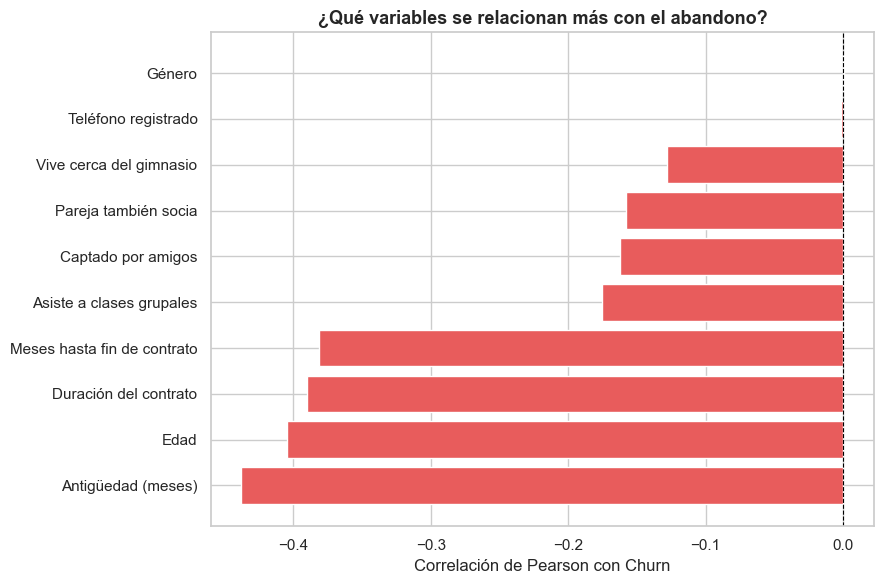

Top 5 variables más correlacionadas con el Churn (valor absoluto):
Antigüedad (meses)             0.438220
Edad                           0.404735
Duración del contrato          0.389984
Meses hasta fin de contrato    0.381393
Asiste a clases grupales       0.175325
Name: Churn, dtype: float64


In [19]:
# Correlación de cada variable con Churn (excluimos el Churn consigo mismo)
corr_churn = df.corr(numeric_only=True)[TARGET].drop(TARGET).sort_values()

# Renombramos el índice al castellano
corr_churn.index = [NOMBRES_ES.get(col, col) for col in corr_churn.index]

# Asignamos color según el signo de la correlación
colores = ['#E85C5C' if v < 0 else '#4C9BE8' for v in corr_churn.values]

plt.figure(figsize=(9, 6))
plt.barh(corr_churn.index, corr_churn.values, color=colores, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.xlabel('Correlación de Pearson con Churn')
plt.title('¿Qué variables se relacionan más con el abandono?', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('../docs/img/06_correlacion_con_churn.png', bbox_inches='tight')
plt.show()

print('Top 5 variables más correlacionadas con el Churn (valor absoluto):')
print(corr_churn.abs().sort_values(ascending=False).head(5))

---
## 11. Conclusiones del Notebook 01

### Calidad del dataset
- **Sin valores nulos.**
- **859 filas con perfil idéntico** en las 11 columnas fiables (no son duplicados reales: con las 3 columnas afectadas por el bug incluidas, no había ninguno — ver celda 5 y celda 18). No se eliminan.
- **Bug de exportación detectado** en `Avg_additional_charges_total`, `Avg_class_frequency_total` y `Avg_class_frequency_current_month`: el separador decimal se confunde con el separador de miles de forma inconsistente fila a fila. No existe una fórmula de reconstrucción fiable al 100% (se probó y se descartó — ver celda 5 y business_case.md, apartado 2.1). Estas 3 columnas se excluyen del resto del proyecto.

###  Distribución del target
- 73.5% activos / 26.5% bajas.


###  Variables más relevantes (primeras conclusiones)

| Variable | Observación |
|----------|-------------|
| Lifetime | Los socios más nuevos abandonan mucho más |
| Age | Los socios más jóvenes tienen mayor riesgo |
| Month_to_end_contract | Menos tiempo de contrato restante = más riesgo |
| Contract_period | Mensual: 42.3% churn / Anual: 2.4% churn |
| Promo_friends | Referidos por amigos abandonan casi la mitad que el resto |
| Group_visits | Asistir a clases grupales reduce el abandono de forma clara |


